In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\medical_prediction_dataset.csv")
df.head()

,Patient_ID,Admission_ID,Admission_Date,Discharge_Date,Age,Sex,Marital_Status,Residence_Type,Insurance_Type,Department,...,Stress_Level,Sleep_Hours,Pain_Score,Temperature_C,Oxygen_Saturation,Medication_Class,Care_Plan,Estimated_Annual_Cost_USD,Patient_Satisfaction_1_5,High_Risk_90_Day
0,P101782,A201782,2026-04-03,2026-04-07,31,Male,Married,Rural,Employer,General Medicine,...,Moderate,3.7,7,37.4,95.4,Statin,Lifestyle,2806.0,3.3,No
1,P103917,A203917,2025-06-05,2025-06-10,49,Female,Widowed,Urban,Employer,Endocrinology,...,High,5.7,1,36.8,96.4,NaN,Lifestyle + Medication,667.0,3.8,No
2,P100221,A200221,2025-10-26,2025-10-29,50,Male,Widowed,Rural,Private,Cardiology,...,Moderate,6.3,0,36.4,98.6,NaN,Lifestyle,2355.0,2.8,No
3,P102135,A202135,2025-03-31,2025-04-04,59,Female,Single,Urban,NHIS,General Medicine,...,Moderate,5.1,3,36.8,95.6,Combination,Specialist Referral,2645.0,5.0,Yes
4,P105224,A205224,2024-04-04,2024-04-06,75,Male,Married,Urban,Private,Emergency,...,High,8.3,2,37.3,95.8,Metformin,Medication,825.0,2.9,No


In [16]:
df.dtypes

Patient_ID                    object
Admission_ID                  object
Admission_Date                object
Discharge_Date                object
Age                            int64
Sex                           object
Marital_Status                object
Residence_Type                object
Insurance_Type                object
Department                    object
Diagnosis_Group               object
BMI                          float64
Smoking_Status                object
Hypertension                  object
Family_History_Diabetes       object
Physical_Activity             object
Diet_Quality                  object
Systolic_BP                    int64
Diastolic_BP                   int64
Heart_Rate                     int64
Glucose_mg_dL                float64
HbA1c_percent                float64
Total_Cholesterol_mg_dL      float64
HDL_mg_dL                    float64
LDL_mg_dL                    float64
Triglycerides_mg_dL          float64
Creatinine_mg_dL             float64
e

In [17]:
df.shape

(6000, 52)

In [18]:
df.isna().sum()

Patient_ID                     0
Admission_ID                   0
Admission_Date                 0
Discharge_Date                 0
Age                            0
Sex                            0
Marital_Status                 0
Residence_Type                 0
Insurance_Type                 0
Department                     0
Diagnosis_Group                0
BMI                            0
Smoking_Status                 0
Hypertension                   0
Family_History_Diabetes        0
Physical_Activity              0
Diet_Quality                   0
Systolic_BP                    0
Diastolic_BP                   0
Heart_Rate                     0
Glucose_mg_dL                  0
HbA1c_percent                  0
Total_Cholesterol_mg_dL        0
HDL_mg_dL                      0
LDL_mg_dL                      0
Triglycerides_mg_dL            0
Creatinine_mg_dL               0
eGFR                           0
Hemoglobin_g_dL                0
WBC_10e9_L                     0
Diabetes_S

In [19]:
# C Length of Stay by Department & Annual Cost by Insurance
# Average length of stay per department
los_by_dept = df.groupby('Department')['Length_of_Stay_Days'].mean().round(2).sort_values(ascending=False)
print("--- Average Length of Stay (Days) ---")
print(los_by_dept)

# Average annual cost per insurance type
cost_by_insurance = df.groupby('Insurance_Type')['Estimated_Annual_Cost_USD'].mean().round(2).sort_values(ascending=False)
print("--- Average Annual Cost (USD) ---")
print(cost_by_insurance)

--- Average Length of Stay (Days) ---
Department
Emergency           3.80
Cardiology          3.77
General Medicine    3.75
Endocrinology       3.62
Outpatient          3.62
Name: Length_of_Stay_Days, dtype: float64
--- Average Annual Cost (USD) ---
Insurance_Type
NHIS        1500.04
Private     1488.22
Employer    1478.29
Self-Pay    1471.58
Name: Estimated_Annual_Cost_USD, dtype: float64


In [20]:
# Q2 - Correlations Across Age Groups
# Bin continuous age into categorical groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 50, 70, 100], labels=['<30', '30-50', '51-70', '>70'])

# Calculate correlation matrix for each group
age_correlations = df.groupby('Age_Group')[['BMI', 'Glucose_mg_dL', 'HbA1c_percent']].corr().round(3)
print("--- Correlation Matrix by Age Group ---")
print(age_correlations)

C:\Users\DELL\AppData\Local\Temp\ipykernel_5388\3321940783.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_correlations = df.groupby('Age_Group')[['BMI', 'Glucose_mg_dL', 'HbA1c_percent']].corr().round(3)


--- Correlation Matrix by Age Group ---
                           BMI  Glucose_mg_dL  HbA1c_percent
Age_Group                                                   
<30       BMI            1.000          0.114          0.104
          Glucose_mg_dL  0.114          1.000          0.731
          HbA1c_percent  0.104          0.731          1.000
30-50     BMI            1.000          0.143          0.096
          Glucose_mg_dL  0.143          1.000          0.759
          HbA1c_percent  0.096          0.759          1.000
51-70     BMI            1.000          0.125          0.087
          Glucose_mg_dL  0.125          1.000          0.807
          HbA1c_percent  0.087          0.807          1.000
>70       BMI            1.000          0.120          0.116
          Glucose_mg_dL  0.120          1.000          0.819
          HbA1c_percent  0.116          0.819          1.000


In [21]:
# CQ3 - Lifestyle Impact on Blood Pressure & Stress
# Blood Pressure by Physical Activity and Diet Quality
bp_summary = df.groupby(['Physical_Activity', 'Diet_Quality'])[['Systolic_BP', 'Diastolic_BP']].mean().round(2)
print("--- Average Blood Pressure by Lifestyle ---")
print(bp_summary)

print("\n")

# Stress Level percentages by Physical Activity and Diet Quality
stress_summary = df.groupby(['Physical_Activity', 'Diet_Quality'])['Stress_Level'].value_counts(normalize=True).unstack().round(3) * 100
print("--- Stress Level Distribution (%) ---")
print(stress_summary)

--- Average Blood Pressure by Lifestyle ---
                                Systolic_BP  Diastolic_BP
Physical_Activity Diet_Quality                           
High              Average            136.90         68.20
                  Good               135.63         67.81
                  Poor               135.79         68.33
Low               Average            136.50         67.91
                  Good               135.21         67.46
                  Poor               137.81         68.55
Moderate          Average            137.09         68.07
                  Good               135.87         67.67
                  Poor               136.32         68.45


--- Stress Level Distribution (%) ---
Stress_Level                    High   Low  Moderate
Physical_Activity Diet_Quality                      
High              Average       22.4  25.1      52.4
                  Good          22.3  27.5      50.2
                  Poor          20.6  29.4      50.0
Low          

# **Visualizations (Seaborn & Matplotlib)**

C:\Users\DELL\AppData\Local\Temp\ipykernel_5388\3088045230.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Estimated_Annual_Cost_USD', palette='Set2')


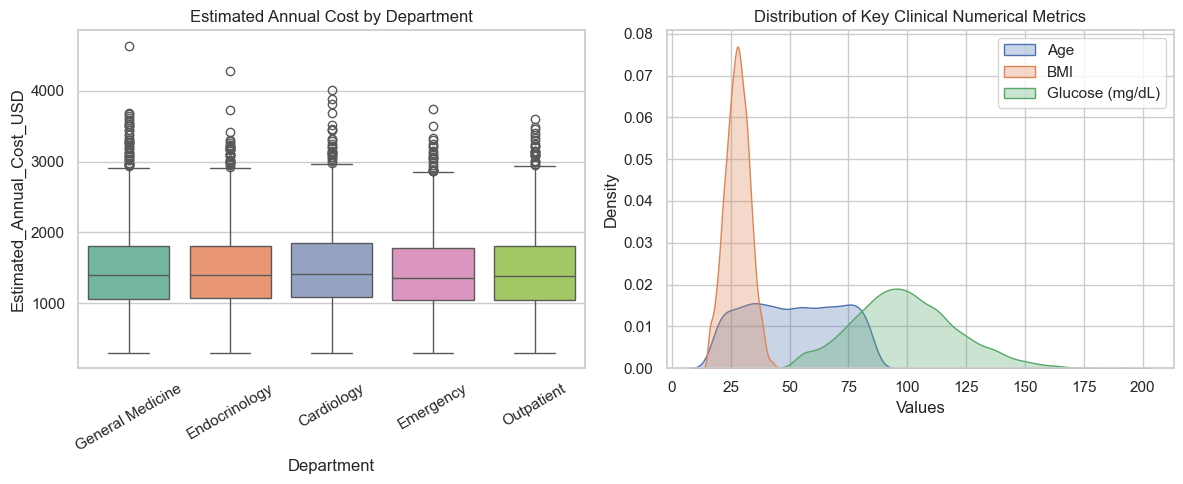

In [22]:
# 1. Distribution & Spread: Boxplot & Histograms/KDE
plt.figure(figsize=(12, 5))

# Boxplot of Annual Cost by Department
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Department', y='Estimated_Annual_Cost_USD', palette='Set2')
plt.title('Estimated Annual Cost by Department')
plt.xticks(rotation=30)

# KDE Histograms for Age, BMI, and Glucose
plt.subplot(1, 2, 2)
sns.kdeplot(df['Age'], label='Age', fill=True, alpha=0.3)
sns.kdeplot(df['BMI'], label='BMI', fill=True, alpha=0.3)
sns.kdeplot(df['Glucose_mg_dL'], label='Glucose (mg/dL)', fill=True, alpha=0.3)
plt.title('Distribution of Key Clinical Numerical Metrics')
plt.xlabel('Values')
plt.legend()

plt.tight_layout()
plt.show()

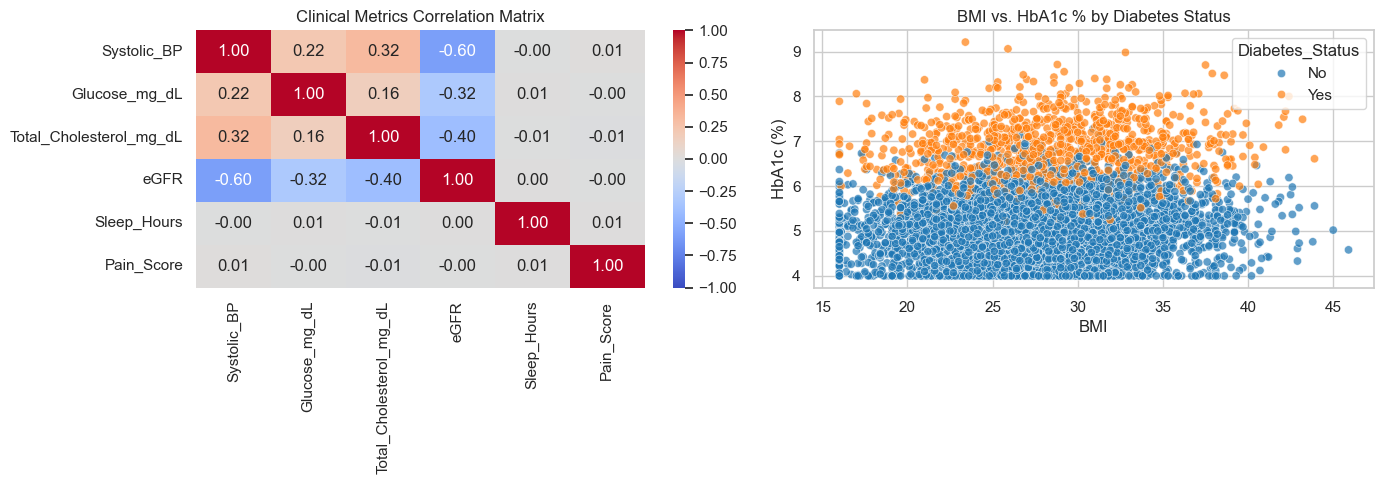

In [23]:
# 2. Correlations & Relationships: Heatmap & Scatter Plot
plt.figure(figsize=(14, 5))

# Correlation Heatmap of Numeric Vitals/Labs
plt.subplot(1, 2, 1)
corr_cols = ['Systolic_BP', 'Glucose_mg_dL', 'Total_Cholesterol_mg_dL', 'eGFR', 'Sleep_Hours', 'Pain_Score']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Clinical Metrics Correlation Matrix')

# Scatter Plot: BMI vs HbA1c by Diabetes Status
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='BMI', y='HbA1c_percent', hue='Diabetes_Status', alpha=0.7, palette='tab10')
plt.title('BMI vs. HbA1c % by Diabetes Status')
plt.xlabel('BMI')
plt.ylabel('HbA1c (%)')

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_5388\943869193.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Care_Plan', y='Patient_Satisfaction_1_5', ci=None, palette='mako')
C:\Users\DELL\AppData\Local\Temp\ipykernel_5388\943869193.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Care_Plan', y='Patient_Satisfaction_1_5', ci=None, palette='mako')


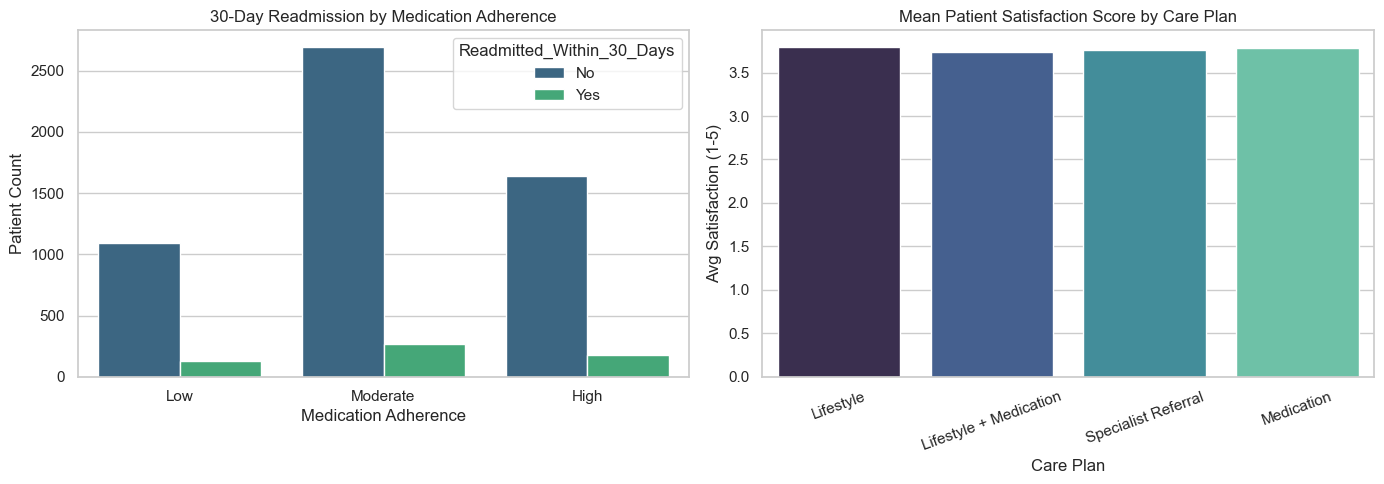

In [24]:
# 3. Category Breakdown: Count Plot & Grouped Bar Chart
plt.figure(figsize=(14, 5))

# Count Plot: Readmission by Medication Adherence
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Medication_Adherence', hue='Readmitted_Within_30_Days', palette='viridis')
plt.title('30-Day Readmission by Medication Adherence')
plt.xlabel('Medication Adherence')
plt.ylabel('Patient Count')

# Grouped Bar Chart: Satisfaction Score by Care Plan
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Care_Plan', y='Patient_Satisfaction_1_5', ci=None, palette='mako')
plt.title('Mean Patient Satisfaction Score by Care Plan')
plt.xlabel('Care Plan')
plt.ylabel('Avg Satisfaction (1-5)')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# **MACHINE LEARNING**

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, r2_score

# 1. Load Data & Preprocess
df['Medication_Class'] = df['Medication_Class'].fillna('Unassigned')

# Define target and feature columns
exclude = ['Patient_ID', 'Admission_ID', 'Admission_Date', 'Discharge_Date', 
           'Readmitted_Within_30_Days', 'High_Risk_90_Day', 'In_Hospital_Mortality', 
           'Length_of_Stay_Days', 'Estimated_Annual_Cost_USD']

X = pd.get_dummies(df.drop(columns=exclude), drop_first=True)

# 2. Train High-Risk 90-Day Classifier
y_risk = (df['High_Risk_90_Day'] == 'Yes').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y_risk, test_size=0.2, random_state=42)

clf_risk = RandomForestClassifier(n_estimators=100, random_state=42)
clf_risk.fit(X_train, y_train)

print("High-Risk 90-Day ROC-AUC:", round(roc_auc_score(y_test, clf_risk.predict_proba(X_test)[:, 1]), 3))

# 3. Train Annual Cost Regressor
y_cost = df['Estimated_Annual_Cost_USD']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_cost, test_size=0.2, random_state=42)

reg_cost = RandomForestRegressor(n_estimators=100, random_state=42)
reg_cost.fit(X_train_c, y_train_c)

y_pred_c = reg_cost.predict(X_test_c)
print("Cost Prediction R2 Score:", round(r2_score(y_test_c, y_pred_c), 3))
print("Cost Prediction RMSE ($):", round(np.sqrt(mean_squared_error(y_test_c, y_pred_c)), 2))

High-Risk 90-Day ROC-AUC: 0.998
Cost Prediction R2 Score: 0.728
Cost Prediction RMSE ($): 325.36
